In [1]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np

from firedrake.petsc import PETSc

In [3]:
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
print(current_path)

/home/aless


---
---
# Exercises 1-2
## Solve nonlinear, steady Navier-Stokes problem.

\begin{equation*}
\begin{cases}
(\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - \nu\Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = 4y(1-y)\boldsymbol{i} & {\rm on} \ \Gamma_{\rm in}, \\
(\nu\nabla\boldsymbol{u} - pI)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_{\rm out}, \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \Gamma_{\rm wall}=\partial\Omega\setminus(\Gamma_{\rm in}\cup\Gamma_{\rm out}). \\
\end{cases}
\end{equation*}

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?


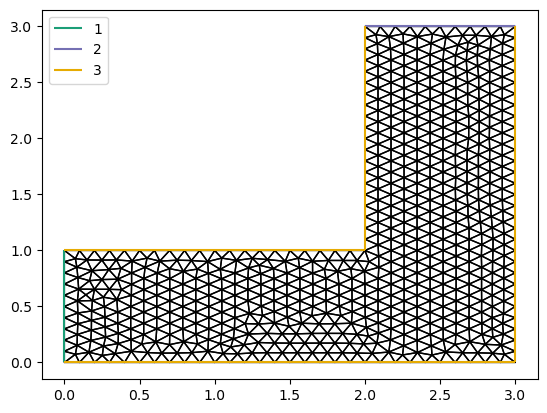

In [4]:
# Import mesh: set the path correctly!
# See cell before Exercise 1 about current path.
mesh = Mesh(current_path + "/cfd-labs/Lab07-NS-nonlinear/elbow1.msh")
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')

In [5]:
# Function spaces (mixed formulation)
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Data and boundary conditions
nu = 0.01
f = Constant((0.,0.))
x = SpatialCoordinate(mesh)
u_in = (4*x[1]*(1-x[1]), 0.)
bc_wall = DirichletBC(W.sub(0), Constant((0.,0.)), 3)
bc_in = DirichletBC(W.sub(0), u_in, 1)
bcs = (bc_wall, bc_in)

### Variational problems

In [6]:
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

def initialization_problem_forms(u, v, p, q, nu, f):
    # Stokes initialization
    a_stokes = nu * inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx
    L_stokes = dot(f, v) * dx
    return a_stokes, L_stokes

def nonlinear_iteration_forms(u, v, p, q, nu, f, u_old):
    # Implementing both fixed-point and Newton methods:
    # uncomment the desired 'return' line.

    # Fixed-point iteration
    a_fp = nu * inner(grad(u), grad(v)) * dx  \
        + inner(dot(grad(u), u_old), v) * dx  \
        - div(v) * p * dx  \
        + q * div(u) * dx
    L_fp = dot(f, v) * dx

    # Newton iteration
    a_Newton = nu * inner(grad(u), grad(v)) * dx \
        + dot(dot(grad(u), u_old), v) * dx \
        + dot(dot(grad(u_old), u), v) * dx \
        - div(v) * p * dx \
        + q * div(u) * dx
    L_Newton = dot(f, v) * dx \
        + dot(dot(grad(u_old), u_old), v) * dx

    return a_fp, L_fp
    return a_Newton, L_Newton

### Initialization and definition of the ***linear*** solver for each nonlinear iteration.

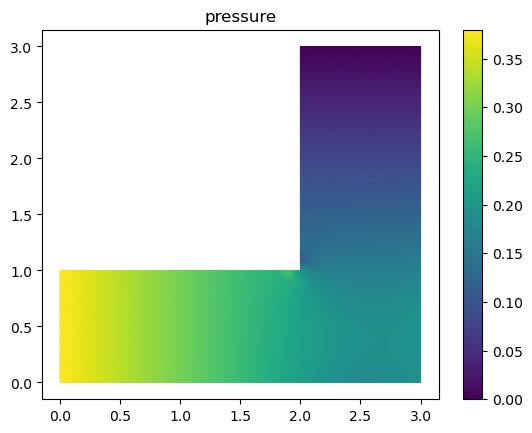

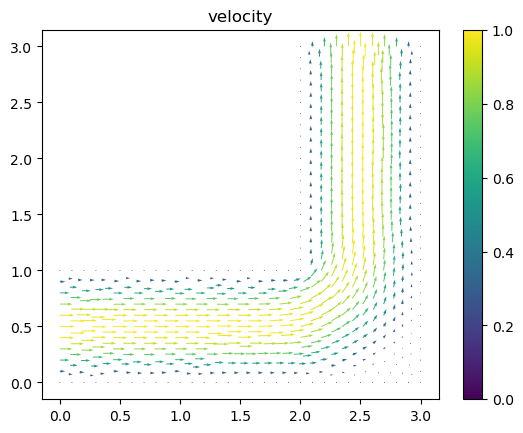

In [ ]:
# Initialization solver
wh_init = Function(W)
a_init, L_init = initialization_problem_forms(u, v, p, q, nu, f)
init_problem = LinearVariationalProblem(a_init, L_init, wh_init, bcs)
param = {'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'}
solver_init =  LinearVariationalSolver(init_problem, solver_parameters=param)

# Actual initialization
solver_init.solve()
uh, ph = wh_init.subfunctions

# Plot of initial guess (Stokes solution)
fig, ax = plt.subplots()
col = tripcolor(ph, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
col = quiver(uh, axes=ax)
plt.colorbar(col)
plt.title('velocity')

# vtk output for Paraview
outfileU = File("/content/drive/MyDrive/CFDlab07/velocity.pvd")
outfileP = File("/content/drive/MyDrive/CFDlab07/pressure.pvd")
uh.rename("Velocity")   # this name will be used in Paraview
ph.rename("Pressure")   # this name will be used in Paraview
outfileU.write(uh)
outfileP.write(ph)

# Nonlinear solver
u_old = Function(V)
u_old.assign(uh)    # copy the dof's of uh (defined over W) into u_old (defined over V)
                    # Do not use 'u_old = uh', which would yield a "shallow copy", by which
                    # u_old would contain a sort of pointer to uh: in such case, any update of uh
                    # would immediately reflect on u_old, whilst we want to keep the two functions
                    # separate from one another, and update them only when actually intended.
p_old = Function(Q)
p_old.assign(ph)
a, L = nonlinear_iteration_forms(u, v, p, q, nu, f, u_old)
wh = Function(W)
problem = LinearVariationalProblem(a, L, wh, bcs)
solver =  LinearVariationalSolver(problem, solver_parameters=param)

### Iterative algorithm for the solution of the nonlinear problem

In [ ]:
maxit = 100
it = 0
tol = 1e-3
err = tol+1     # >tol in order to enter the loop at the beginning

while it <= maxit and err > tol:

    it += 1

    # solve problem associated with one iteration
    solver.solve()
    uh, ph = wh.subfunctions


    err = (errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') +
           errornorm(ph, p_old, 'L2') / norm(p_old, 'L2'))

    print("Iteration = ", it, " Error = ", err)
    uh.rename("Velocity")
    ph.rename("Pressure")
    outfileU.write(uh)
    outfileP.write(ph)

    # u_old = uh #NO! It would destroy the pointers within the solver
    u_old.assign(uh) # update the old solution
    p_old.assign(ph) # update the old solution

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver di NOT converge!\nRelative error =', err, 'after', it, 'iterations.')

Iteration =  1  Error =  1.0937381047680397
Iteration =  2  Error =  0.315491365252177
Iteration =  3  Error =  0.17014651990562665
Iteration =  4  Error =  0.07509143804748196
Iteration =  5  Error =  0.023279958201429682
Iteration =  6  Error =  0.006135739966875237
Iteration =  7  Error =  0.002016658165015586
Iteration =  8  Error =  0.0007659301426193698
Nonlinear solver converged in 8 iterations.


In [ ]:
fig, ax = plt.subplots()
col = tripcolor(ph, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
col = quiver(uh, axes=ax)
plt.colorbar(col)
plt.title('velocity')